In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.ticker as mtick
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

df = pd.read_csv('titanic_train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


데이터 상태 점검
 * 전체 구조 확인
 * 결측치 확인

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

결측치 처리
 * 나이는 평균값으로 채우고 확인

In [10]:
mean_age = df['Age'].mean()
mean_age

np.float64(29.69911764705882)

In [11]:
df['Age'] = df['Age'].fillna(mean_age)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
df = df.drop('Ticket', axis=1)
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked', 'Age_group'],
      dtype='object')

In [15]:
df['Age_group'] = pd.cut(df['Age'], bins=range(0,101,10), right=False, 
                         labels=[f"{i}대" for i in range(0, 100, 10)])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,20대
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,30대
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,20대
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,30대
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,30대


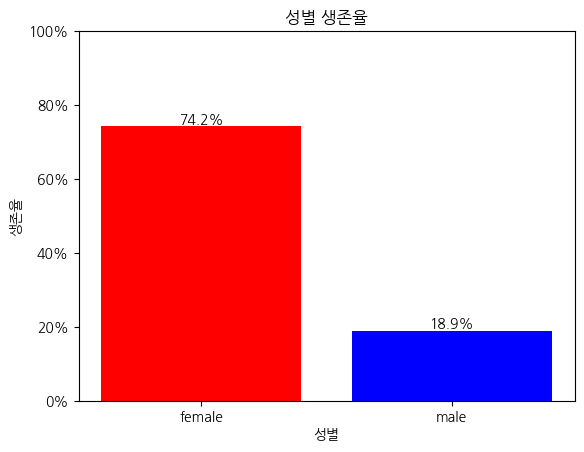

In [31]:
bars = plt.bar(survived_by_sex.index, survived_by_sex, color=['red','blue'])
plt.bar_label(bars, labels= survived_by_sex.map(lambda v : f"{v*100:.1f}%"))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0,1)
plt.xlabel('성별')
plt.ylabel('생존율')
plt.title('성별 생존율')
plt.show()

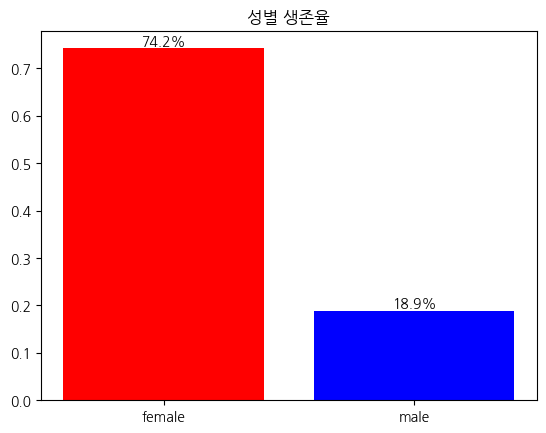

In [13]:
bars = plt.bar(survived_by_sex.index, survived_by_sex.values, color=['red','blue'])
plt.bar_label(bars, labels=[f"{v*100:.1f}%" for v in survived_by_sex])
plt.title('성별 생존율')
plt.show()

## Pclass별 생존율

In [33]:
survived_by_class = df.groupby('Pclass')['Survived'].mean()
survived_by_class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

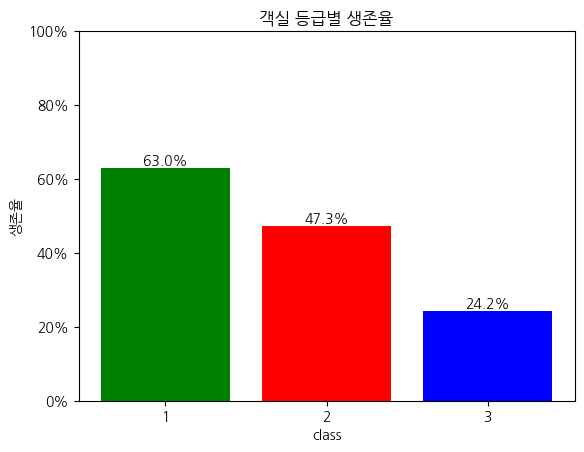

In [43]:
bars = plt.bar(survived_by_class.index, survived_by_class, color=['green','red','blue'])
plt.xlabel('class')
plt.ylabel('생존율')
plt.bar_label(bars, labels=survived_by_class.map(lambda v : f"{v*100:.1f}%"))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('객실 등급별 생존율')
plt.xticks(survived_by_class.index)
plt.ylim(0,1)
plt.show()

## 연령대별 생존율

In [21]:
df['Age_group'] = pd.cut(df['Age'], bins=range(0,101,10), right=False, 
                         labels=[f"{i}대" for i in range(0, 100, 10)])

In [22]:
s_by_age = df.groupby('Age_group')['Survived'].mean()
s_by_age

C:\Users\User\AppData\Local\Temp\ipykernel_29716\2332180248.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s_by_age = df.groupby('Age_group')['Survived'].mean()


Age_group
0대     0.612903
10대    0.401961
20대    0.324937
30대    0.437126
40대    0.382022
50대    0.416667
60대    0.315789
70대    0.000000
80대    1.000000
90대         NaN
Name: Survived, dtype: float64

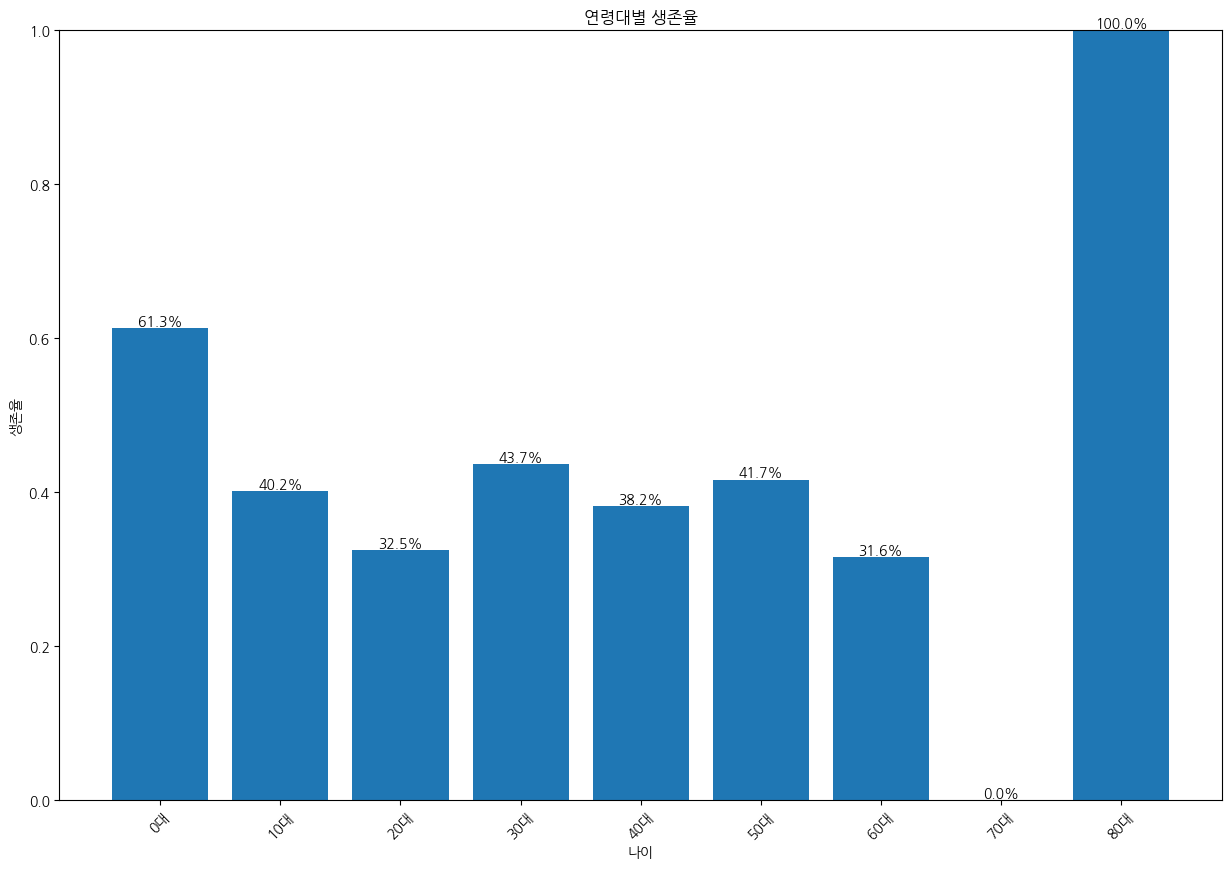

In [78]:
plt.figure(figsize=(15,10))

bars = plt.bar(
    s_by_age.index.astype(str), 
    s_by_age.values
)

plt.xlabel('나이')
plt.ylabel('생존율')
plt.title('연령대별 생존율')

plt.bar_label(
    bars,
    labels=[f"{v*100:.1f}%" for v in s_by_age]
)

plt.xticks(rotation=45)
plt.ylim(0,1)

plt.show()

In [72]:
s_by_SibSp = df.groupby('SibSp')['Survived'].mean()
s_by_SibSp

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

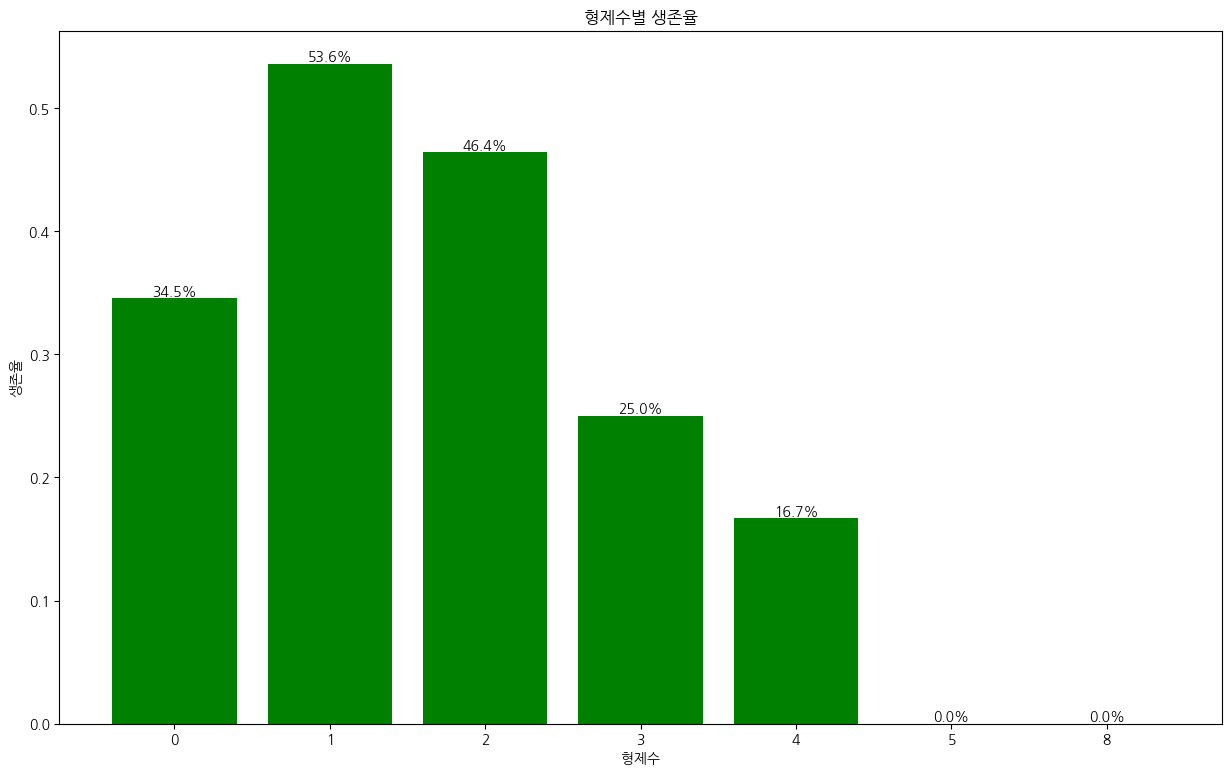

In [77]:
plt.figure(figsize=(15,9))

bars = plt.bar(
    s_by_SibSp.index.astype(str), 
    s_by_SibSp.values, color='green'
)

plt.xlabel('형제수')
plt.ylabel('생존율')
plt.title('형제수별 생존율')

plt.bar_label(
    bars,
    labels=[f"{v*100:.1f}%" for v in s_by_SibSp]
)

plt.xticks

plt.show()